## Worksheet5
## Student Name: Puspa Raj Chaudhary
## Student ID: 2408828


## Extract File

In [29]:
import zipfile

# Path to your zip file
zip_path = "/content/FruitinAmazon.zip"

# Destination folder
extract_path = "/content/extracted_files"

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

## Setup & Imports

In [30]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from sklearn.metrics import classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


--- ## Dataset Path Configuration > **Set `BASE_DIR` to the folder where you extracted `FruitAmazon.zip`.** > Expected structure: ``` FruitAmazon/     train/         acai/         cupuacu/         graviola/         guarana/         pupunha/         tucuma/     test/         acai/         ... ```

In [31]:
BASE_DIR  = "/content/extracted_files/FruitinAmazon"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Hyperparameters
IMG_HEIGHT     = 128
IMG_WIDTH      = 128
BATCH_SIZE     = 16
EPOCHS         = 250
VAL_SPLIT      = 0.2
LEARNING_RATE  = 0.001

# Auto-detect number of classes
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES})")

Classes (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma'])



## Task 1 — Data Understanding and Visualization

### 1.1 Visualise one random image per class

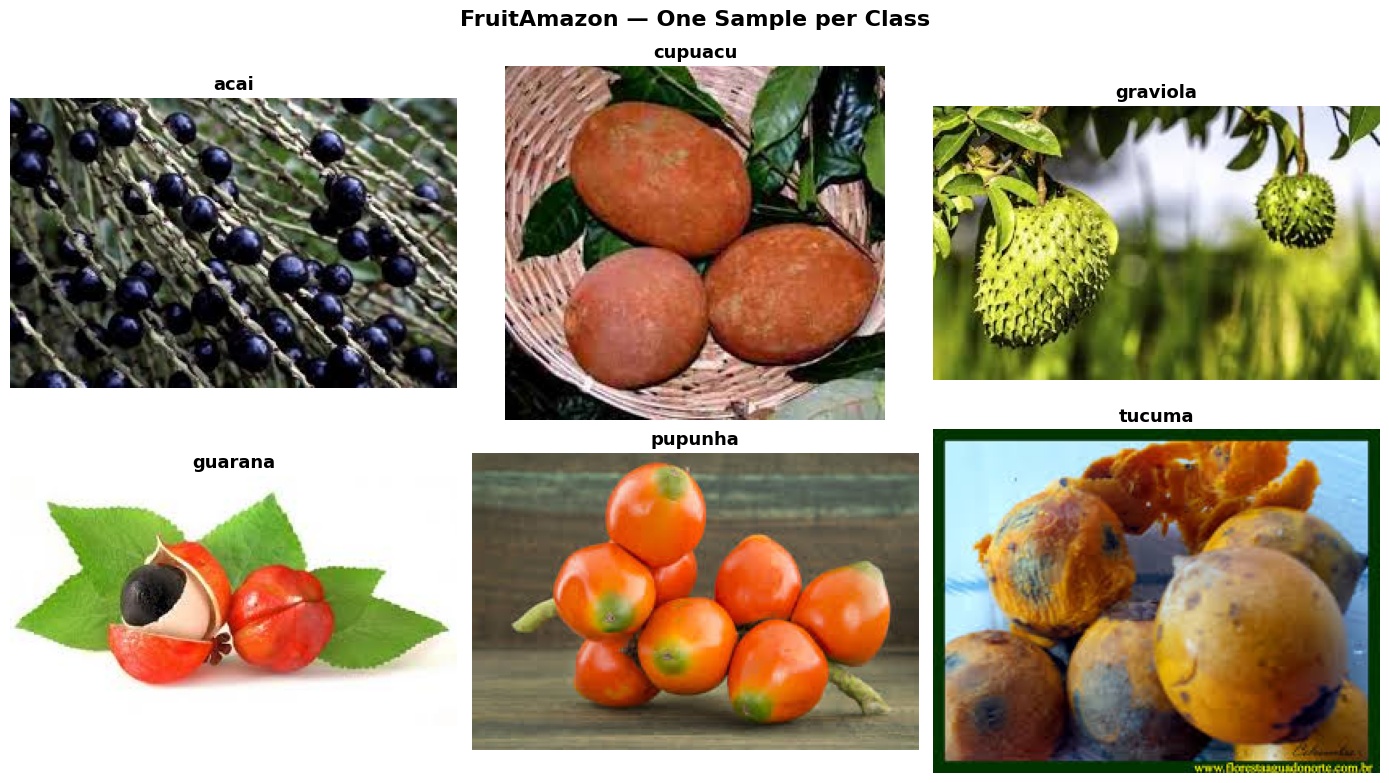

Saved: task1_sample_images.png


In [32]:
class_dirs = sorted(os.listdir(TRAIN_DIR))

n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 8))
axes = axes.flatten()

for idx, cls in enumerate(class_dirs):
    cls_path  = os.path.join(TRAIN_DIR, cls)
    images    = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_file  = random.choice(images)
    img_path  = os.path.join(cls_path, img_file)
    img       = mpimg.imread(img_path)

    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=13, fontweight='bold')
    axes[idx].axis('off')

# Hide any extra subplots
for j in range(len(class_dirs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("FruitAmazon — One Sample per Class", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("task1_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task1_sample_images.png")

**Observation:**  
The dataset contains 6 Amazonian fruit classes: *acai, cupuacu, graviola, guarana, pupunha,* and *tucuma*.  
Images vary in background, lighting, and scale, making the classification task non-trivial.  
Some classes (e.g. graviola, guarana) have very distinct shapes and colours, which should help the CNN learn discriminative features more easily.

### 1.2 Check for Corrupted Images

In [33]:
corrupted_images = []

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for img_file in os.listdir(cls_path):
        image_path = os.path.join(cls_path, img_file)
        try:
            img = Image.open(image_path)
            img.verify()          # Detect truncated / corrupt headers
        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.



## Task 2 — Loading and Preprocessing Image Data

In [35]:
# Rescaling layer  (pixel values 0-255 → 0-1)
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ---------- Training dataset ----------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# ---------- Validation dataset ----------
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# ---------- Test dataset ----------
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Performance optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets loaded successfully.")
print(f"Class names: {CLASS_NAMES}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Datasets loaded successfully.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



## Task 3 — Build the CNN Model

In [36]:
def build_cnn(input_shape, num_classes):
    model = keras.Sequential([

        # ── Convolutional Block 1
        layers.Conv2D(filters=32, kernel_size=(3, 3),
                      strides=(1, 1), padding='same',
                      input_shape=input_shape),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),

        # ── Convolutional Block 2
        layers.Conv2D(filters=32, kernel_size=(3, 3),
                      strides=(1, 1), padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),

        # ── Fully Connected Network
        layers.Flatten(),

        layers.Dense(64, activation='relu'),   # Hidden Layer 1
        layers.Dense(128, activation='relu'),  # Hidden Layer 2
        layers.Dropout(0.5),                   # Regularisation

        layers.Dense(num_classes, activation='softmax')  # Output Layer
    ], name='FruitAmazon_CNN')

    return model


model = build_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=NUM_CLASSES
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "FruitAmazon_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)


## Task 4 — Compile and Train the Model

### 4a. Compile

In [37]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled.")

Model compiled.


### 4b. Callbacks

In [38]:
checkpoint_cb = ModelCheckpoint(
    filepath='best_fruit_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=20,          # Stop if no improvement for 20 epochs
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint_cb, early_stop_cb]
print("Callbacks ready: ModelCheckpoint + EarlyStopping")

Callbacks ready: ModelCheckpoint + EarlyStopping


### 4c. Train

In [39]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.1382 - loss: 1.9878
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_fruit_cnn.h5



Epoch 1: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step - accuracy: 0.1389 - loss: 2.1161 - val_accuracy: 0.8333 - val_loss: 1.5059
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.3017 - loss: 1.7746
Epoch 2: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.3056 - loss: 1.7273 - val_accuracy: 0.1111 - val_loss: 1.7833
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.3455 - loss: 1.6229
Epoch 3: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 0.3472 - loss: 1.6391 - val_accuracy: 0.2222 - val_loss: 1.7116
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.3774 - loss: 1.5147
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - accuracy: 0.4028 - loss: 1.4977 - val_accuracy: 0.1667 - val_loss: 1.6253
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.4990 - loss: 1


Epoch 12: finished saving model to best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - accuracy: 0.9028 - loss: 0.3580 - val_accuracy: 0.9444 - val_loss: 0.3886
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.8608 - loss: 0.3976
Epoch 13: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.9028 - loss: 0.3051 - val_accuracy: 0.8889 - val_loss: 0.3574
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9837 - loss: 0.1308
Epoch 14: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.9861 - loss: 0.1209 - val_accuracy: 0.7778 - val_loss: 0.6666
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9899 - loss: 0.0930
Epoch 15: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - accuracy: 0.9861 - loss: 0.1166 - val_accuracy: 0.8333 - val_loss: 0.4404
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9837 -

### Training & Validation Curves

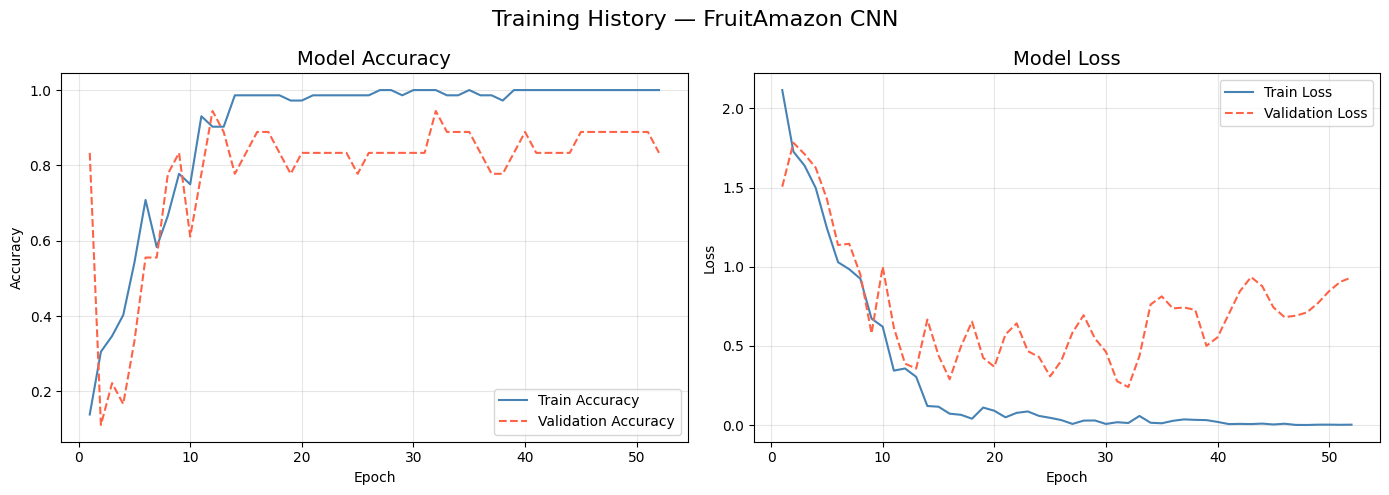

Saved: training_curves.png


In [40]:
def plot_history(history):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(epochs_range, acc,     label='Train Accuracy',      color='steelblue')
    ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='tomato', linestyle='--')
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(epochs_range, loss,     label='Train Loss',      color='steelblue')
    ax2.plot(epochs_range, val_loss, label='Validation Loss', color='tomato', linestyle='--')
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Training History — FruitAmazon CNN', fontsize=16)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")

plot_history(history)

---
## Task 5 — Evaluate the Model on the Test Set

In [42]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8333 - loss: 1.0033
Test Loss    : 1.0033
Test Accuracy: 0.8333  (83.33%)



## Task 6 — Save and Reload the Model

In [43]:
# Save
MODEL_PATH = 'fruit_amazon_cnn_final.h5'
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Load
loaded_model = keras.models.load_model(MODEL_PATH)
print("Model loaded successfully.")

# Re-evaluate
reloaded_loss, reloaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nReloaded model — Test Accuracy: {reloaded_acc:.4f}")

Model saved to: fruit_amazon_cnn_final.h5
Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8333 - loss: 1.0033

Reloaded model — Test Accuracy: 0.8333



## Task 7 — Predictions and Classification Report

In [44]:
# Collect true labels and predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Classification Report
              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       1.00      1.00      1.00         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.83      1.00      0.91         5
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.83        30
   macro avg       0.88      0.83      0.80        30
weighted avg       0.88      0.83      0.80        30



### Visualise Predictions vs Ground Truth

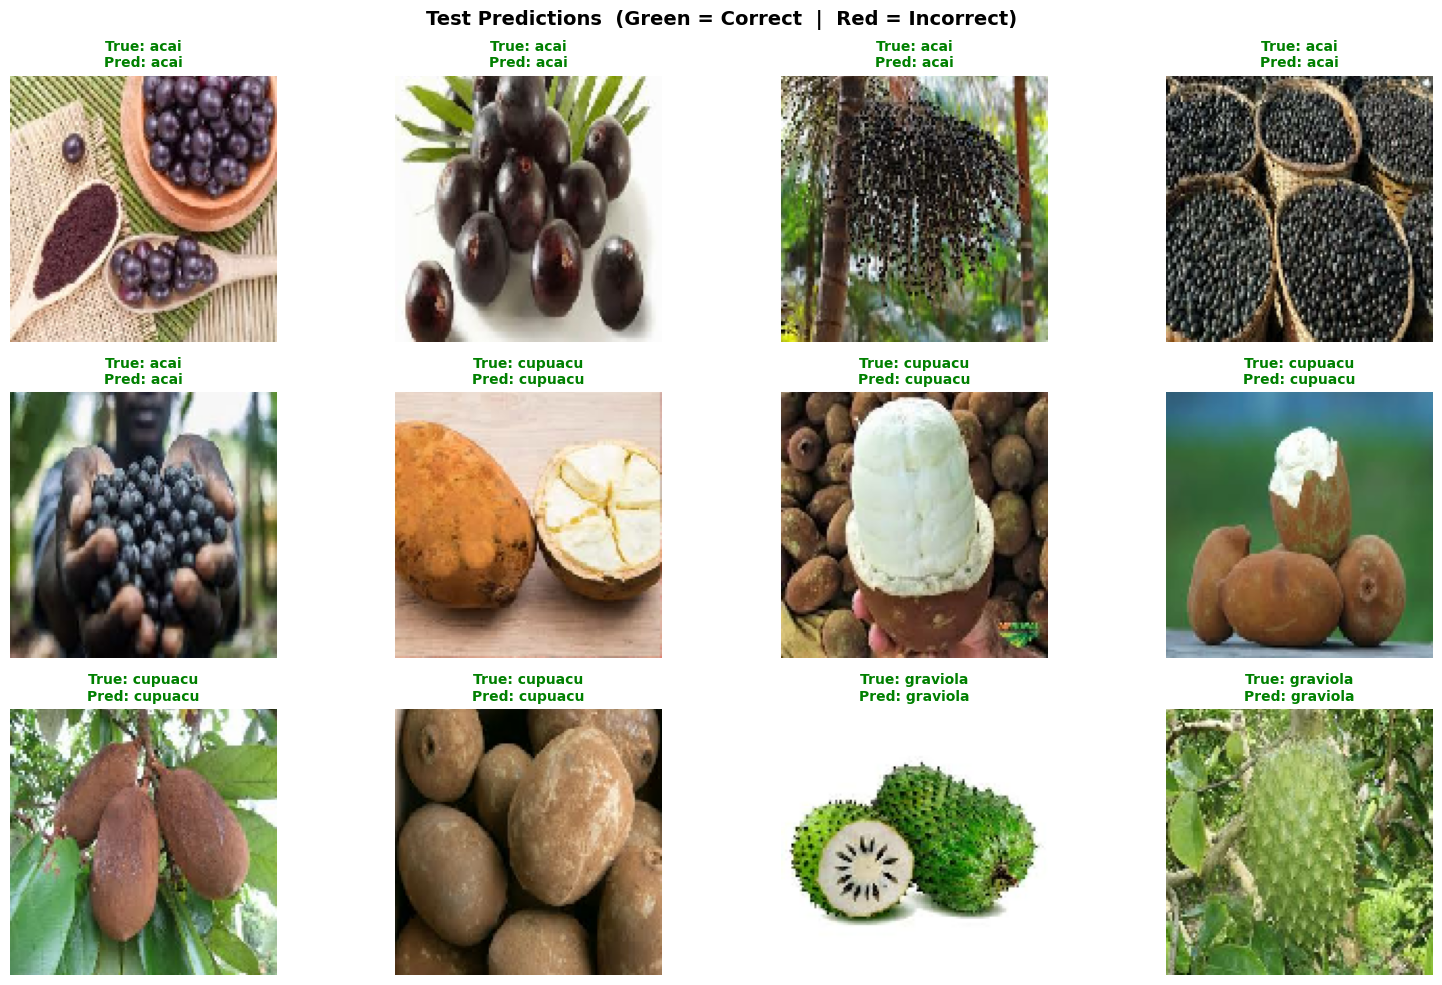

Saved: predictions_grid.png


In [45]:
# Show first 12 test images with predicted and actual labels
sample_images, sample_labels = next(iter(test_ds))
sample_preds = loaded_model.predict(sample_images, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

n_show = min(12, len(sample_images))
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i in range(n_show):
    axes[i].imshow(sample_images[i].numpy())
    true_cls  = CLASS_NAMES[sample_labels[i].numpy()]
    pred_cls  = CLASS_NAMES[sample_pred_labels[i]]
    correct   = (true_cls == pred_cls)
    color     = 'green' if correct else 'red'
    axes[i].set_title(
        f"True: {true_cls}\nPred: {pred_cls}",
        fontsize=10, color=color, fontweight='bold'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Test Predictions  (Green = Correct  |  Red = Incorrect)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: predictions_grid.png")